# Import Package

In [102]:
import pandas as Endy_pd
import numpy as Endy_np
import datetime as Endy_dt
import matplotlib.pyplot as Endy_plt
import seaborn as Endy_sea
import matplotlib.colors as Endy_cl
from operator import attrgetter
from scipy import stats

In [2]:
import os
os.getcwd()

'D:\\Jupyter'

In [75]:
#pip install operator

# Import Data CSV

In [76]:
data_asli = Endy_pd.read_csv('Online Retail Data.csv', header = 0)
data_asli

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN
...,...,...,...,...,...,...,...
461768,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,NaN
461769,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,NaN
461770,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,NaN
461771,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,NaN


In [77]:
data_asli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


# Membersihkan dan Memproses Data

In [78]:
data_bersih = data_asli.copy()

#Konversi order_date menjadi datetime
data_bersih['order_date'] = data_bersih['order_date'].astype('datetime64[ns]')

#Membuat kolom year_month
data_bersih['year_month'] = data_bersih['order_date'].dt.to_period('M')

#Membuat kolom date
data_bersih['date'] = Endy_pd.to_datetime(data_bersih['order_date']).dt.date

#Pilih baris dari customer_id yang tidak NaN
data_bersih = data_bersih[~data_bersih['customer_id'].isna()]

#Pilih barus dari product_name yang tidak NaN
data_bersih = data_bersih[~data_bersih['product_name'].isna()]

#Standarisasi product_name menjadi huruf kecil semua
data_bersih['product_name'] = data_bersih['product_name'].str.lower()

#Menghapus TEST pada product_code atau product_name
data_bersih = data_bersih[
    (~data_bersih['product_code'].str.lower().str.contains('test')) |
    (~data_bersih['product_name'].str.contains('test'))]

#Membuat status order berdasarkan order_id
data_bersih['order_status'] = Endy_np.where(data_bersih['order_id'].str[:1] == 'C', 'Cancelled', 'Delivered')

#Menghilangkan nilai negatif menjadi positif
data_bersih['quantity'] = data_bersih['quantity'].abs()

#Mengilangkan nilai negatif pada price 
data_bersih = data_bersih[data_bersih['price'] >= 1]

#Membuat amount berdasarkan quantity dan price
data_bersih['amount'] = data_bersih['quantity'] * data_bersih['price']

#Menghitung produk_name yang paling sering muncul
banyaknya_produk_name = data_bersih.groupby(['product_code', 'product_name'], as_index = False).agg(banyak_order = ('order_id', 'nunique')).sort_values(['product_name', 'banyak_order'], ascending = [True, False])
banyaknya_produk_name['rank'] = banyaknya_produk_name.groupby('product_code')['banyak_order'].rank(method = 'first', ascending = False)
banyaknya_produk_name = banyaknya_produk_name[banyaknya_produk_name['rank'] == 1].drop(columns = ['banyak_order', 'rank'])
data_bersih = data_bersih.merge(banyaknya_produk_name.rename(columns = {'product_name' : 'banyaknya_produk_name'}), how = 'left', on = 'product_code')
data_bersih['product_name'] = data_bersih['banyaknya_produk_name']
data_bersih = data_bersih.drop(columns = 'banyaknya_produk_name')

#Mengubah customer_id menjadi string 
data_bersih['customer_id'] = data_bersih['customer_id'].astype(str)

#Menghilangkan outlier
data_bersih = data_bersih[(Endy_np.abs(stats.zscore(data_bersih[['quantity', 'amount', 'price']])) < 3).all(axis = 1)]
data_bersih = data_bersih.reset_index(drop = True)

#Membuat price_category
jumlah_bin = Endy_np.linspace(data_bersih['price'].min(), data_bersih['price'].max(), 4)
kategori = ['Cheap', 'Medium', 'Expensive']
data_bersih['price_category'] = Endy_pd.cut(data_bersih['price'], jumlah_bin, labels = kategori, include_lowest = True)

#Membuang data duplikat
data_bersih.drop_duplicates(inplace = True)

data_bersih

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount,price_category
0,C493411,21539,red retrospot butter dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,2010-01-04,Cancelled,4.25,Cheap
1,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01-04,Delivered,91.80,Cheap
2,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01-04,Delivered,51.00,Cheap
3,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01-04,Delivered,5.10,Cheap
4,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01-04,Delivered,8.50,Cheap
...,...,...,...,...,...,...,...,...,...,...,...,...
284128,539988,84380,set of 3 butterfly cookie cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,2010-12-23,Delivered,1.25,Cheap
284129,539988,84849D,hot baths soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,2010-12-23,Delivered,1.69,Cheap
284130,539988,84849B,fairy soap soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,2010-12-23,Delivered,1.69,Cheap
284131,539988,22854,cream sweetheart egg holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,2010-12-23,Delivered,9.90,Cheap


In [79]:
data_bersih.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279024 entries, 0 to 284132
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        279024 non-null  object        
 1   product_code    279024 non-null  object        
 2   product_name    279024 non-null  object        
 3   quantity        279024 non-null  int64         
 4   order_date      279024 non-null  datetime64[ns]
 5   price           279024 non-null  float64       
 6   customer_id     279024 non-null  object        
 7   year_month      279024 non-null  period[M]     
 8   date            279024 non-null  object        
 9   order_status    279024 non-null  object        
 10  amount          279024 non-null  float64       
 11  price_category  279024 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(6), period[M](1)
memory usage: 25.8+ MB


# EDA

## Explore Data

In [8]:
data_eda3 = data_bersih.copy()
data_eda3.set_index('price_category', inplace = True)

data_eda3.loc['Expensive']

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount
price_category,,,,,,,,,,,
Expensive,495753,ADJUST,adjustment by john on 26/01/2010 17,1,2010-01-26 16:29:00,178.31,14653.0,2010-01,2010-01-26,Delivered,178.31
Expensive,C501678,M,manual,1,2010-03-18 16:18:00,241.38,16943.0,2010-03,2010-03-18,Cancelled,241.38
Expensive,502602,M,manual,1,2010-03-25 13:34:00,241.38,16943.0,2010-03,2010-03-25,Delivered,241.38
Expensive,C504648,M,manual,1,2010-04-15 14:48:00,210.47,17949.0,2010-04,2010-04-15,Cancelled,210.47
Expensive,C504670,M,manual,1,2010-04-15 15:16:00,227.28,17452.0,2010-04,2010-04-15,Cancelled,227.28
Expensive,C506485,D,discount,1,2010-04-30 10:37:00,216.45,15498.0,2010-04,2010-04-30,Cancelled,216.45
Expensive,C511793,M,manual,1,2010-06-10 14:12:00,241.38,16943.0,2010-06,2010-06-10,Cancelled,241.38
Expensive,512804,M,manual,1,2010-06-18 11:16:00,241.38,16943.0,2010-06,2010-06-18,Delivered,241.38
Expensive,C523171,M,manual,1,2010-09-20 15:54:00,229.46,17284.0,2010-09,2010-09-20,Cancelled,229.46


In [9]:
data_bersih.loc[data_bersih['product_name'].str.contains('retrospot')]

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount,price_category
0,C493411,21539,red retrospot butter dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,2010-01-04,Cancelled,4.25,Cheap
1,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01-04,Delivered,91.80,Cheap
5,493414,21527,red retrospot traditional teapot,12,2010-01-04 10:28:00,6.95,14590.0,2010-01,2010-01-04,Delivered,83.40,Cheap
6,493414,21531,red retrospot sugar jam bowl,24,2010-01-04 10:28:00,2.10,14590.0,2010-01,2010-01-04,Delivered,50.40,Cheap
7,C493415,21527,red retrospot traditional teapot,3,2010-01-04 10:33:00,7.95,14590.0,2010-01,2010-01-04,Cancelled,23.85,Cheap
...,...,...,...,...,...,...,...,...,...,...,...,...
283987,C539950,85099B,jumbo bag red retrospot,10,2010-12-23 11:50:00,1.95,13534.0,2010-12,2010-12-23,Cancelled,19.50,Cheap
284009,539981,21485,retrospot heart hot water bottle,3,2010-12-23 14:35:00,4.95,13304.0,2010-12,2010-12-23,Delivered,14.85,Cheap
284010,539981,85099B,jumbo bag red retrospot,10,2010-12-23 14:35:00,1.95,13304.0,2010-12,2010-12-23,Delivered,19.50,Cheap
284041,539985,22667,recipe box retrospot,24,2010-12-23 15:16:00,2.55,15856.0,2010-12,2010-12-23,Delivered,61.20,Cheap


In [10]:
data_bersih.describe()

,quantity,order_date,price,amount
count,279024.000000,279024,279024.000000,279024.000000
mean,7.029603,2010-07-21 17:28:35.820359680,3.676190,18.284403
min,1.000000,2010-01-04 09:43:00,1.000000,1.000000
25%,2.000000,2010-04-22 18:09:00,1.650000,4.950000
50%,4.000000,2010-08-01 13:48:00,2.550000,12.750000
75%,9.000000,2010-10-25 11:43:30,4.250000,19.500000
max,104.000000,2010-12-23 16:06:00,241.380000,340.000000
std,10.962022,NaN,4.383236,25.553724


### Explore product_name

In [11]:
data_bersih['product_name'].count()

np.int64(279024)

In [12]:
data_bersih['product_name'].unique()

array(['red retrospot butter dish', 'red retrospot mug',
       'retro spot large milk jug', ..., 'easter tin keepsake',
       'queens guard coffee mug', 'edwardian drop earrings jet black'],
      shape=(3085,), dtype=object)

In [13]:
data_bersih['product_name'].value_counts()

product_name
white hanging heart t-light holder     2869
regency cakestand 3 tier               1664
jumbo bag red retrospot                1521
strawberry ceramic trinket box         1243
lunch bag red spotty                   1186
                                       ... 
blue drop earrings w bead cluster         1
seagrass s/3 squ laundry box              1
ruby glass cluster earrings               1
glass and painted beads bracelet ol       1
edwardian drop earrings jet black         1
Name: count, Length: 3085, dtype: int64

## Penyebaran dan Pemusatan Data

### Mean

In [14]:
#Mean dari Price
mean_price = data_bersih['price'].mean()
print(f'Mean dari price: {mean_price}')

#Mean dari quantity
mean_quantity = data_bersih['quantity'].mean()
print(f'Mean dari quantity: {mean_quantity}')

#Mean dari amount
mean_amount = data_bersih['amount'].mean()
print(f'Mean dari amount: {mean_amount}')

Mean dari price: 3.6761896467687363
Mean dari quantity: 7.029603188256208
Mean dari amount: 18.28440295458455


### Modus

In [15]:
#Modus dari price
modus_price = data_bersih['price'].mode()[0]
print(f'Modus dari price: {modus_price}')

#Modus dari quantity
modus_quantity = data_bersih['quantity'].mode()[0]
print(f'Modus dari quantity: {modus_quantity}')

#Modus dari amount
modus_amount = data_bersih['amount'].mode()[0]
print(f'Modus dari amount: {modus_amount}')

#Modus dari product_code
modus_procode = data_bersih['product_code'].mode()[0]
print(f'Modus dari product_code: {modus_procode}')

#Modus dari product_name
modus_proname = data_bersih['product_name'].mode()[0]
print(f'Modus dari product_name: {modus_proname}')

#Modus dari order_status
modus_status = data_bersih['order_status'].mode()[0]
print(f'Modus dari order_status: {modus_status}')

#Modus dari year_month
modus_bulan = data_bersih['year_month'].mode()[0]
print(f'Modus dari year_month: {modus_bulan}')

Modus dari price: 1.25
Modus dari quantity: 1
Modus dari amount: 15.0
Modus dari product_code: 85123A
Modus dari product_name: white hanging heart t-light holder
Modus dari order_status: Delivered
Modus dari year_month: 2010-11


In [16]:
data_eda = data_bersih.copy()
data_eda.set_index('product_code', inplace = True)

#Mengakses modus poduct_code
data_eda.loc['85123A']

,order_id,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount,price_category
product_code,,,,,,,,,,,
85123A,C493430,white hanging heart t-light holder,1,2010-01-04 11:43:00,2.95,14680.0,2010-01,2010-01-04,Cancelled,2.95,Cheap
85123A,493432,white hanging heart t-light holder,32,2010-01-04 12:30:00,2.55,14680.0,2010-01,2010-01-04,Delivered,81.60,Cheap
85123A,C493445,white hanging heart t-light holder,2,2010-01-04 14:00:00,2.95,16296.0,2010-01,2010-01-04,Cancelled,5.90,Cheap
85123A,493543,white hanging heart t-light holder,5,2010-01-04 16:29:00,2.95,14839.0,2010-01,2010-01-04,Delivered,14.75,Cheap
85123A,493568,white hanging heart t-light holder,12,2010-01-05 09:16:00,2.95,16875.0,2010-01,2010-01-05,Delivered,35.40,Cheap
...,...,...,...,...,...,...,...,...,...,...,...
85123A,539836,white hanging heart t-light holder,5,2010-12-22 13:46:00,2.95,17894.0,2010-12,2010-12-22,Delivered,14.75,Cheap
85123A,539867,white hanging heart t-light holder,6,2010-12-23 10:38:00,2.95,13922.0,2010-12,2010-12-23,Delivered,17.70,Cheap
85123A,539920,white hanging heart t-light holder,4,2010-12-23 11:06:00,2.95,14085.0,2010-12,2010-12-23,Delivered,11.80,Cheap


### Median

In [17]:
#Median dari price
median_price = data_bersih['price'].median()
print(f'Median dari price: {median_price}')

#Median dari quantity
median_quantity = data_bersih['quantity'].median()
print(f'Median dari quantity: {median_quantity}')

#Median dari amount
median_amount = data_bersih['amount'].median()
print(f'Median dari amount: {median_amount}')

Median dari price: 2.55
Median dari quantity: 4.0
Median dari amount: 12.75


### Jangkauan

In [18]:
#Jangkauan dari price
range_price = data_bersih['price'].max() - data_bersih['price'].min()
print(f'Jangkauan dari price: {range_price}')

#Jangkauan dari quantity
range_quantity = data_bersih['quantity'].max() - data_bersih['quantity'].min()
print(f'Jangkauan dari quantity: {range_quantity}')

#Jangkauan dari amount
range_amount = data_bersih['amount'].max() - data_bersih['amount'].min()
print(f'Jangkauan dari amount: {range_amount}')

Jangkauan dari price: 240.38
Jangkauan dari quantity: 103
Jangkauan dari amount: 339.0


In [19]:
#Price
print(f'Max dari price: {data_bersih['price'].max()}')
print(f'Min dari price: {data_bersih['price'].min()}')
print()

#Quantity
print(f'Max dari quantity: {data_bersih['quantity'].max()}')
print(f'Min dari quantity: {data_bersih['quantity'].min()}')
print()

#Amount
print(f'Max dari amount: {data_bersih['amount'].max()}')
print(f'Min dari amount: {data_bersih['amount'].min()}')

Max dari price: 241.38
Min dari price: 1.0

Max dari quantity: 104
Min dari quantity: 1

Max dari amount: 340.0
Min dari amount: 1.0


In [20]:
data_eda2 = data_asli.copy()
data_eda2.set_index('price', inplace = True)

data_eda2.loc[210.47]

order_id                    C504648
product_code                      M
product_name                 Manual
quantity                         -1
order_date      2010-04-15 14:48:00
customer_id                 17949.0
Name: 210.47, dtype: object

In [21]:
data_eda2.loc[0.001]

,order_id,product_code,product_name,quantity,order_date,customer_id
price,,,,,,
0.001,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,16705.0
0.001,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,13583.0
0.001,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,17350.0
0.001,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,13408.0
0.001,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,13408.0
0.001,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,15182.0
0.001,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,13765.0
0.001,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,14459.0
0.001,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,14857.0


### Standar Deviasi

In [22]:
#Standar Deviasi Price
std_price = data_bersih['price'].std()
print(f'Standar Deviasi price: {std_price}')

#Standar Deviasi Quantity
std_quant = data_bersih['quantity'].std()
print(f'Standar Deviasi quantity: {std_quant}')

#Standar Deviasi amount
std_amount = data_bersih['amount'].std()
print(f'Standar Deviasi amount: {std_amount}')

Standar Deviasi price: 4.383236032966973
Standar Deviasi quantity: 10.96202236219891
Standar Deviasi amount: 25.553724383440414


### Varian

In [23]:
#Varian price
var_price = data_bersih['price'].var()
print(f'Varian dari price: {var_price}')

#Varian quantity
var_quant = data_bersih['quantity'].var()
print(f'Varian dari quantity: {var_quant}')

#Varian amount
var_amount = data_bersih['amount'].var()
print(f'Varian dari amount: {var_amount}')

Varian dari price: 19.212758120700048
Varian dari quantity: 120.16593426934897
Varian dari amount: 652.9928298648372


### Quartile

In [24]:
#Quartile price
print("=" * 15, "Price", "=" * 15)
q1_price = data_bersih['price'].quantile(.25)
q2_price = data_bersih['price'].quantile(.5)
q3_price = data_bersih['price'].quantile(.75)
print(f'Q1 dari price: {q1_price}')
print(f'Q2 dari price: {q2_price}')
print(f'Q3 dari price: {q3_price}')
print()

#Quartile quantity
print('=' * 13, 'Quantity', '=' * 14)
q1_quant = data_bersih['quantity'].quantile(.25)
q2_quant = data_bersih['quantity'].quantile(.5)
q3_quant = data_bersih['quantity'].quantile(.75)
print(f'Q1 dari quantity: {q1_quant}')
print(f'Q2 dari quantity: {q2_quant}')
print(f'Q3 dari quantity: {q3_quant}')
print()

#Quartile amount
print('=' * 14, 'Amount', '=' * 15)
q1_amount = data_bersih['amount'].quantile(.25)
q2_amount = data_bersih['amount'].quantile(.5)
q3_amount = data_bersih['amount'].quantile(.75)
print(f'Q1 dari amount: {q1_amount}')
print(f'Q2 dari amount: {q2_amount}')
print(f'Q3 dari amount: {q3_amount}')

=============== Price ===============
Q1 dari price: 1.65
Q2 dari price: 2.55
Q3 dari price: 4.25

============= Quantity ==============
Q1 dari quantity: 2.0
Q2 dari quantity: 4.0
Q3 dari quantity: 9.0

============== Amount ===============
Q1 dari amount: 4.95
Q2 dari amount: 12.75
Q3 dari amount: 19.5


### Interquartile

In [25]:
#IQR price
iqr_price = q3_price - q1_price
print(f'Interquartile dari price: {iqr_price}')

#IQR quantity
iqr_quant = q3_quant - q1_quant
print(f'Interquartile dari quantity: {iqr_quant}')

#IQR amount
iqr_amount = q3_amount - q1_amount
print(f'Interquartile dari amount: {iqr_amount}')

Interquartile dari price: 2.6
Interquartile dari quantity: 7.0
Interquartile dari amount: 14.55


## Visualisasi

### Pivot Table

In [80]:
#Pivot table user tiap bulan
data_bulanan_customer = data_bersih.groupby(['customer_id', 'year_month'], as_index = False).agg(
    order_count = ('order_id', 'nunique')
)
data_bulanan_customer

,customer_id,year_month,order_count
0,12346.0,2010-01,1
1,12346.0,2010-03,1
2,12346.0,2010-06,2
3,12346.0,2010-10,1
4,12608.0,2010-10,1
...,...,...,...
11888,18286.0,2010-06,1
11889,18286.0,2010-08,1
11890,18287.0,2010-05,1
11891,18287.0,2010-09,2


In [81]:
data_bulanan_customer['cohort'] = data_bulanan_customer.groupby('customer_id')['year_month'].transform('min')
data_bulanan_customer

,customer_id,year_month,order_count,cohort
0,12346.0,2010-01,1,2010-01
1,12346.0,2010-03,1,2010-01
2,12346.0,2010-06,2,2010-01
3,12346.0,2010-10,1,2010-01
4,12608.0,2010-10,1,2010-10
...,...,...,...,...
11888,18286.0,2010-06,1,2010-06
11889,18286.0,2010-08,1,2010-06
11890,18287.0,2010-05,1,2010-05
11891,18287.0,2010-09,2,2010-05


In [94]:
data_bulanan_customer['period_num'] = (data_bulanan_customer['year_month'] - data_bulanan_customer['cohort']).apply(attrgetter('n')) + 1
data_bulanan_customer = data_bulanan_customer.drop(columns = ['periud_num'])
data_bulanan_customer

,customer_id,year_month,order_count,cohort,period_num
0,12346.0,2010-01,1,2010-01,1
1,12346.0,2010-03,1,2010-01,3
2,12346.0,2010-06,2,2010-01,6
3,12346.0,2010-10,1,2010-01,10
4,12608.0,2010-10,1,2010-10,1
...,...,...,...,...,...
11888,18286.0,2010-06,1,2010-06,1
11889,18286.0,2010-08,1,2010-06,3
11890,18287.0,2010-05,1,2010-05,1
11891,18287.0,2010-09,2,2010-05,5


In [92]:
data_cohort_pivot = Endy_pd.pivot_table(
    data_bulanan_customer, index = 'cohort', columns = 'period_num',
    values = 'customer_id', aggfunc = Endy_pd.Series.nunique
)
data_cohort_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,706.0,274.0,327.0,307.0,300.0,298.0,287.0,263.0,275.0,315.0,332.0,244.0
2010-02,457.0,154.0,130.0,162.0,151.0,120.0,119.0,158.0,152.0,166.0,100.0,NaN
2010-03,521.0,146.0,158.0,144.0,140.0,118.0,144.0,185.0,192.0,95.0,NaN,NaN
2010-04,321.0,82.0,74.0,64.0,68.0,79.0,99.0,102.0,50.0,NaN,NaN,NaN
2010-05,268.0,52.0,49.0,50.0,50.0,69.0,66.0,43.0,NaN,NaN,NaN,NaN
2010-06,266.0,50.0,56.0,60.0,64.0,85.0,37.0,NaN,NaN,NaN,NaN,NaN
2010-07,173.0,36.0,36.0,51.0,53.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,157.0,34.0,50.0,48.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,225.0,63.0,60.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
pembagi_cohort = data_cohort_pivot.iloc[:, 0]
pembagi_cohort

cohort
2010-01    706.0
2010-02    457.0
2010-03    521.0
2010-04    321.0
2010-05    268.0
2010-06    266.0
2010-07    173.0
2010-08    157.0
2010-09    225.0
2010-10    363.0
2010-11    322.0
2010-12     65.0
Freq: M, Name: 1, dtype: float64

In [99]:
data_retention = data_cohort_pivot.divide(pembagi_cohort, axis = 0)
data_retention

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.388102,0.463173,0.434844,0.424929,0.422096,0.406516,0.372521,0.389518,0.446176,0.470255,0.345609
2010-02,1.0,0.336980,0.284464,0.354486,0.330416,0.262582,0.260394,0.345733,0.332604,0.363239,0.218818,NaN
2010-03,1.0,0.280230,0.303263,0.276392,0.268714,0.226488,0.276392,0.355086,0.368522,0.182342,NaN,NaN
2010-04,1.0,0.255452,0.230530,0.199377,0.211838,0.246106,0.308411,0.317757,0.155763,NaN,NaN,NaN
2010-05,1.0,0.194030,0.182836,0.186567,0.186567,0.257463,0.246269,0.160448,NaN,NaN,NaN,NaN
2010-06,1.0,0.187970,0.210526,0.225564,0.240602,0.319549,0.139098,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.208092,0.208092,0.294798,0.306358,0.167630,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.216561,0.318471,0.305732,0.165605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.280000,0.266667,0.137778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
#Pivot table date
Endy_pd.pivot_table(data_bersih, index = 'date',
                   columns = 'order_status', values = ['order_id', 'amount'],
                   aggfunc = {
                       'order_id': Endy_pd.Series.nunique,
                       'amount': Endy_np.sum
                   },
                   fill_value = 0)

C:\Users\Acer\AppData\Local\Temp\ipykernel_10764\2334995904.py:2: FutureWarning: The provided callable <function sum at 0x000002011BC525C0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Endy_pd.pivot_table(data_bersih, index = 'date',


amount            order_id          
order_status Cancelled Delivered Cancelled Delivered
date                                                
2010-01-04      239.43   6012.90        10        22
2010-01-05       67.20  12895.21         3        29
2010-01-06        0.00   6848.81         0        11
2010-01-07      609.36  15039.67        31        37
2010-01-08       21.90  11905.79         1        33
...                ...       ...       ...       ...
2010-12-19       17.60   5163.78         2        16
2010-12-20      891.39  12799.36        21        42
2010-12-21      111.80   4736.22         7        19
2010-12-22       65.40   3253.71         5        11
2010-12-23      206.15   3579.00         8        14

[298 rows x 4 columns]

In [27]:
#Pivot Table year_month
Endy_pd.pivot_table(data_bersih, index = 'year_month',
                   columns = 'price_category', values = ['amount'],
                   aggfunc = {'amount': Endy_np.sum},
                   fill_value = 0)

C:\Users\Acer\AppData\Local\Temp\ipykernel_10764\1878387161.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  Endy_pd.pivot_table(data_bersih, index = 'year_month',
C:\Users\Acer\AppData\Local\Temp\ipykernel_10764\1878387161.py:2: FutureWarning: The provided callable <function sum at 0x000002011BC525C0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Endy_pd.pivot_table(data_bersih, index = 'year_month',


amount                   
price_category      Cheap   Medium Expensive
year_month                                  
2010-01         287900.18   425.78    178.31
2010-02         313184.63   327.84      0.00
2010-03         424984.21   612.70    482.76
2010-04         390042.45  1062.29    654.20
2010-05         380426.80   571.99      0.00
2010-06         386214.59   517.31    482.76
2010-07         356150.04   700.50      0.00
2010-08         356686.36   625.00      0.00
2010-09         469389.71  1162.75   1100.76
2010-10         628053.17  1369.15   1045.59
2010-11         731998.34  1926.58    825.00
2010-12         359515.50  2665.00    505.00

### Grafik Batang

In [28]:
data_batang = data_bersih.groupby('order_status', as_index = False).agg(order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum'))
data_batang

,order_status,order_count,total_amount
0,Cancelled,3361,120189.07
1,Delivered,15999,4981598.18


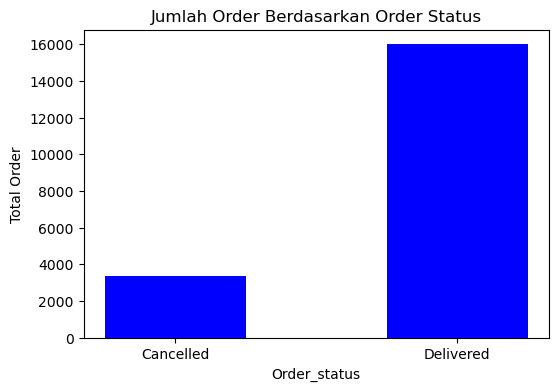

In [29]:
#Grafik batang ke atas untuk jumlah order beerdasarkan order status
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.bar(data_batang['order_status'], data_batang['order_count'],
            color = 'blue', width = 0.5)
Endy_plt.xlabel('Order_status')
Endy_plt.ylabel('Total Order')
Endy_plt.title('Jumlah Order Berdasarkan Order Status')
Endy_plt.show()

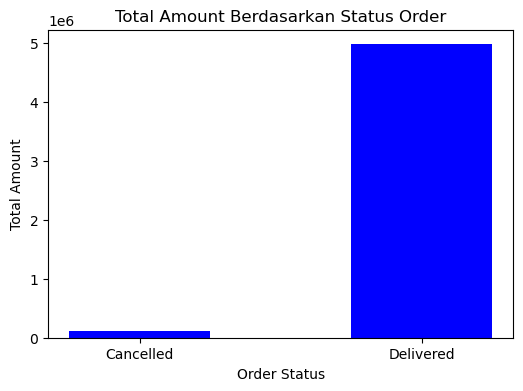

In [30]:
#Grafik batang ke atas untuk jumlah amount berdasarkan status order
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.bar(data_batang['order_status'], data_batang['total_amount'],
            color = 'blue', width = 0.5)
Endy_plt.xlabel('Order Status')
Endy_plt.ylabel('Total Amount')
Endy_plt.title('Total Amount Berdasarkan Status Order')
Endy_plt.show()

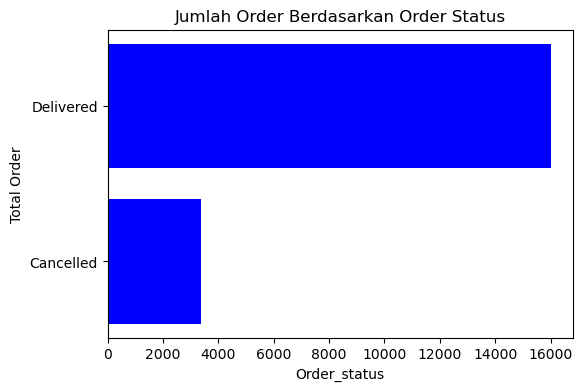

In [31]:
#Grafik batang menyamping untuk jumlah order beerdasarkan order status
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.barh(data_batang['order_status'], data_batang['order_count'],
            color = 'blue')
Endy_plt.xlabel('Order_status')
Endy_plt.ylabel('Total Order')
Endy_plt.title('Jumlah Order Berdasarkan Order Status')
Endy_plt.show()

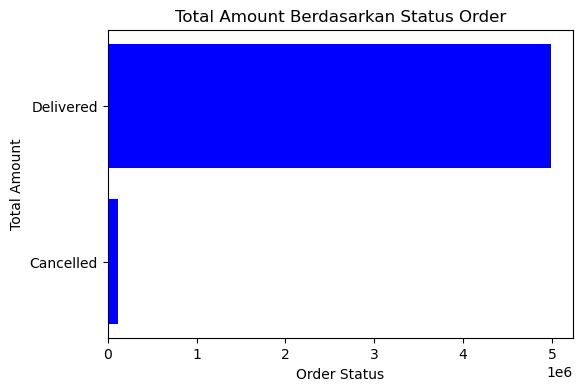

In [32]:
#Grafik batang ke atas untuk jumlah amount berdasarkan status order
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.barh(data_batang['order_status'], data_batang['total_amount'],
            color = 'blue')
Endy_plt.xlabel('Order Status')
Endy_plt.ylabel('Total Amount')
Endy_plt.title('Total Amount Berdasarkan Status Order')
Endy_plt.show()

In [33]:
data_batang2 = data_bersih.groupby('price_category', as_index = False).agg(order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum'))
data_batang2

C:\Users\Acer\AppData\Local\Temp\ipykernel_10764\4012051991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_batang2 = data_bersih.groupby('price_category', as_index = False).agg(order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum'))


,price_category,order_count,total_amount
0,Cheap,19297,5084545.98
1,Medium,77,11966.89
2,Expensive,27,5274.38


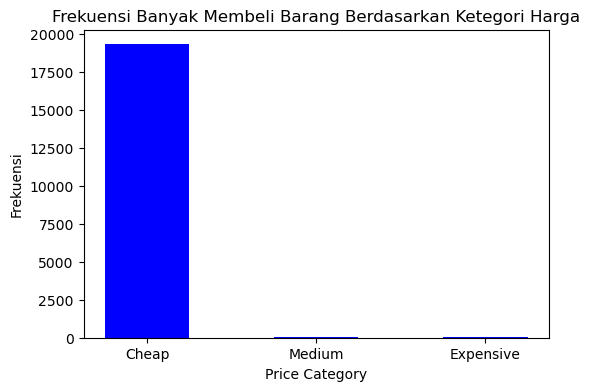

In [34]:
#Grafik Batang untuk price_category
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.bar(data_batang2['price_category'], data_batang2['order_count'],
            color = 'blue', width = 0.5)
Endy_plt.xlabel('Price Category')
Endy_plt.ylabel('Frekuensi')
Endy_plt.title('Frekuensi Banyak Membeli Barang Berdasarkan Ketegori Harga')
Endy_plt.show()

### Histogram

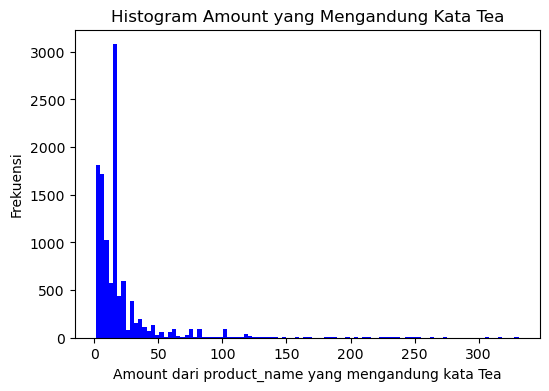

In [35]:
#Histogram Amount berdasarkan product_name
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.hist(data_bersih.loc[data_bersih['product_name'].str.contains('tea'), 'amount'], 100, 
              color = 'blue')
Endy_plt.title('Histogram Amount yang Mengandung Kata Tea')
Endy_plt.xlabel('Amount dari product_name yang mengandung kata Tea')
Endy_plt.ylabel('Frekuensi')
Endy_plt.show()

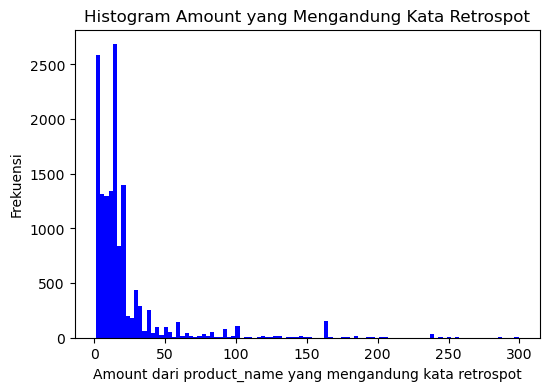

In [36]:
#Histogram Amount yang mengandung kata retrospot
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.hist(data_bersih.loc[data_bersih['product_name'].str.contains('retrospot'), 'amount'],
             100, color = 'blue')
Endy_plt.title('Histogram Amount yang Mengandung Kata Retrospot')
Endy_plt.xlabel('Amount dari product_name yang mengandung kata retrospot')
Endy_plt.ylabel('Frekuensi')
Endy_plt.show()

### Line Chart

In [37]:
data_line = data_bersih.groupby('year_month', as_index = False).agg(order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum'))
data_line

,year_month,order_count,total_amount
0,2010-01,1094,288504.27
1,2010-02,1143,313512.47
2,2010-03,1638,426079.67
3,2010-04,1401,391758.94
4,2010-05,1544,380998.79
5,2010-06,1573,387214.66
6,2010-07,1483,356850.54
7,2010-08,1324,357311.36
8,2010-09,1701,471653.22
9,2010-10,2226,630467.91


In [38]:
data_line['year_month'] = data_line['year_month'].astype(str)
data_line.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year_month    12 non-null     object 
 1   order_count   12 non-null     int64  
 2   total_amount  12 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 420.0+ bytes


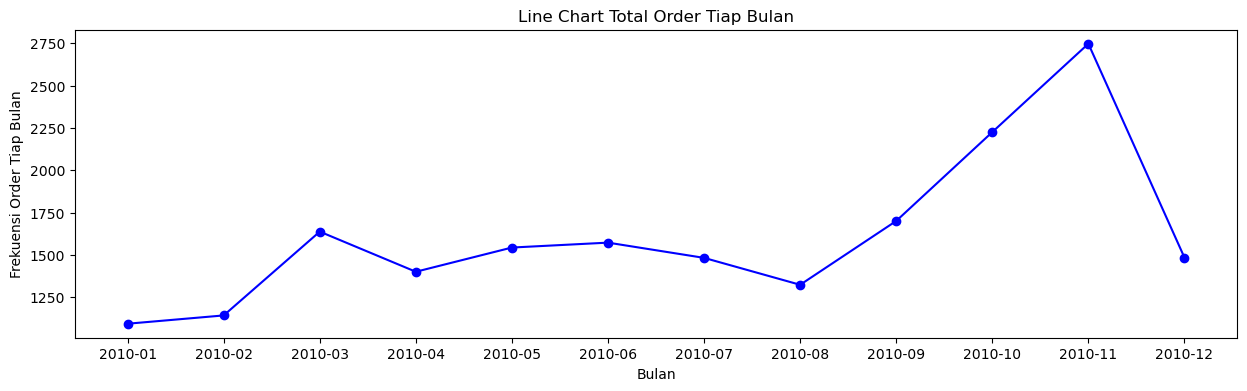

In [39]:
#Line Chart Total Order Tiap Bulan
ukuran = Endy_plt.figure(figsize = (15, 4))
Endy_plt.plot('year_month', 'order_count', data = data_line,
             color = 'blue', marker = 'o', linestyle = '-')
Endy_plt.title('Line Chart Total Order Tiap Bulan')
Endy_plt.xlabel('Bulan')
Endy_plt.ylabel('Frekuensi Order Tiap Bulan')
Endy_plt.show()

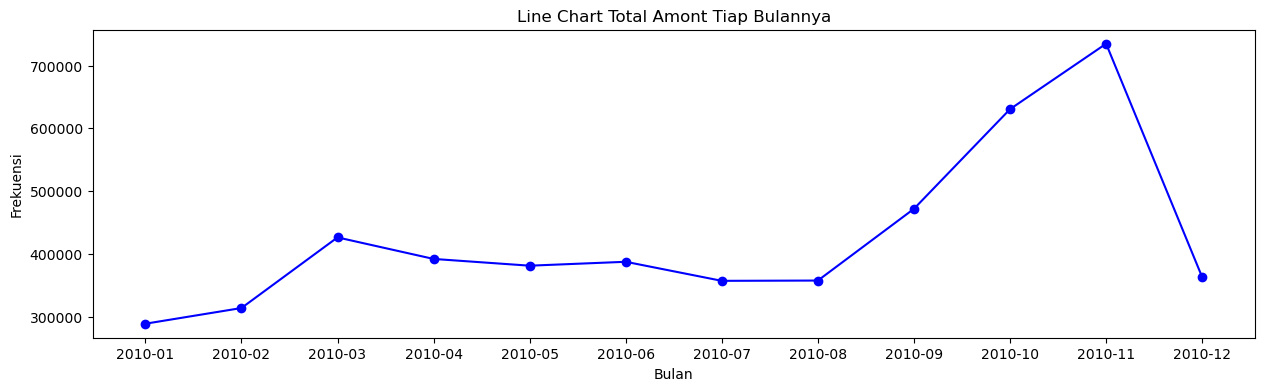

In [40]:
#Line Chart Total Amount Tiap Bulannya 
ukuran = Endy_plt.figure(figsize = (15, 4))
Endy_plt.plot('year_month', 'total_amount', data = data_line,
             color = 'blue', marker = 'o',linestyle = '-')
Endy_plt.xlabel('Bulan')
Endy_plt.ylabel('Frekuensi')
Endy_plt.title('Line Chart Total Amont Tiap Bulannya')
Endy_plt.show()

### Pie-chart

In [41]:
data_pie = data_bersih.groupby('order_status', as_index = False).agg(
    order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum'))
data_pie

,order_status,order_count,total_amount
0,Cancelled,3361,120189.07
1,Delivered,15999,4981598.18


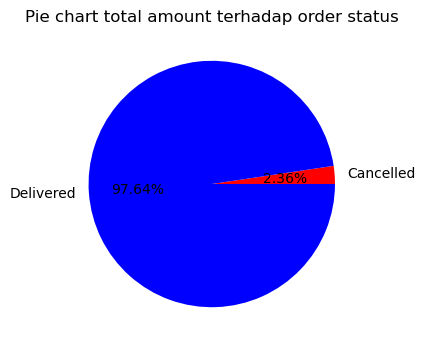

In [42]:
#Pie chart total amount terhadap order status
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.pie(data_pie['total_amount'], labels = data_pie['order_status'],
            startangle = 0, autopct = '%1.2f%%', colors = ['red', 'blue'])
Endy_plt.title('Pie chart total amount terhadap order status')
Endy_plt.show()

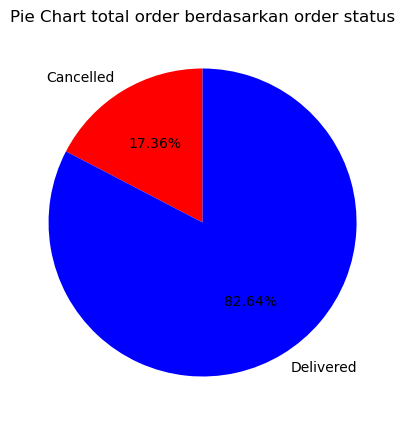

In [43]:
#Pie chart total order terhadap order status
ukuran = Endy_plt.figure(figsize = (7, 5))
Endy_plt.pie(data_pie['order_count'], labels = data_pie['order_status'],
            startangle = 90, autopct = '%1.2f%%', colors = ['red', 'blue'])
Endy_plt.title('Pie Chart total order berdasarkan order status')
Endy_plt.show()

In [44]:
data_pie2 = data_bersih.groupby('price_category', as_index = False).agg(
    order_count = ('order_id', 'nunique'), total_amount = ('amount', 'sum')
)
data_pie2

C:\Users\Acer\AppData\Local\Temp\ipykernel_10764\3995847551.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_pie2 = data_bersih.groupby('price_category', as_index = False).agg(


,price_category,order_count,total_amount
0,Cheap,19297,5084545.98
1,Medium,77,11966.89
2,Expensive,27,5274.38


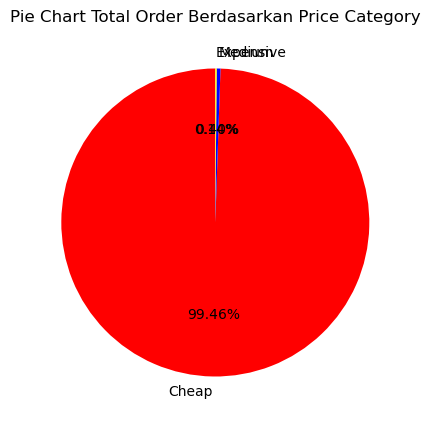

In [45]:
#Pie chart total order berdasarkan price category
ukuran = Endy_plt.figure(figsize = (7, 5))
Endy_plt.pie(data_pie2['order_count'], labels = data_pie2['price_category'],
            startangle = 90, autopct = '%1.2f%%', colors = ['red', 'blue', 'yellow'])
Endy_plt.title('Pie Chart Total Order Berdasarkan Price Category')
Endy_plt.show()

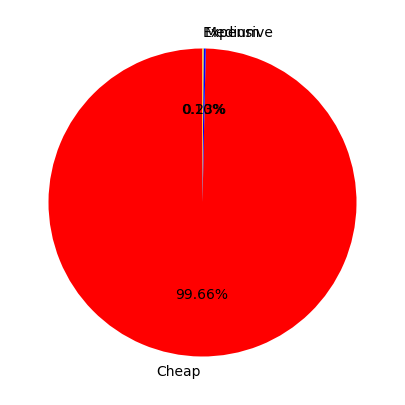

In [46]:
#Pie Chart total amount berdasarkan price category
ukuran = Endy_plt.figure(figsize = (7, 5))
Endy_plt.pie(data_pie2['total_amount'], labels = data_pie2['price_category'],
            startangle = 90, autopct = '%1.2f%%', colors = ['red', 'blue', 'yellow'])
Endy_plt.show()

### Scatter Plot

In [47]:
data_scatter = data_bersih[data_bersih['product_name'].str.contains('tea')]
data_scatter

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount,price_category
5,493414,21527,red retrospot traditional teapot,12,2010-01-04 10:28:00,6.95,14590.0,2010-01,2010-01-04,Delivered,83.40,Cheap
7,C493415,21527,red retrospot traditional teapot,3,2010-01-04 10:33:00,7.95,14590.0,2010-01,2010-01-04,Cancelled,23.85,Cheap
49,C493430,21527,red retrospot traditional teapot,1,2010-01-04 11:43:00,7.95,14680.0,2010-01,2010-01-04,Cancelled,7.95,Cheap
93,493432,22072,red retrospot tea cup and saucer,2,2010-01-04 12:30:00,3.75,14680.0,2010-01,2010-01-04,Delivered,7.50,Cheap
95,493432,21527,red retrospot traditional teapot,5,2010-01-04 12:30:00,7.95,14680.0,2010-01,2010-01-04,Delivered,39.75,Cheap
...,...,...,...,...,...,...,...,...,...,...,...,...
283898,C539857,47567B,tea time kitchen apron,1,2010-12-22 15:13:00,4.65,15358.0,2010-12,2010-12-22,Cancelled,4.65,Cheap
283924,539920,21069,vintage billboard tea mug,6,2010-12-23 11:06:00,1.25,14085.0,2010-12,2010-12-23,Delivered,7.50,Cheap
283928,539920,84946,antique silver tea glass etched,12,2010-12-23 11:06:00,1.25,14085.0,2010-12,2010-12-23,Delivered,15.00,Cheap
283977,539933,21216,"set 3 red spot tin tea,coffee,sugar",4,2010-12-23 11:24:00,4.95,15235.0,2010-12,2010-12-23,Delivered,19.80,Cheap


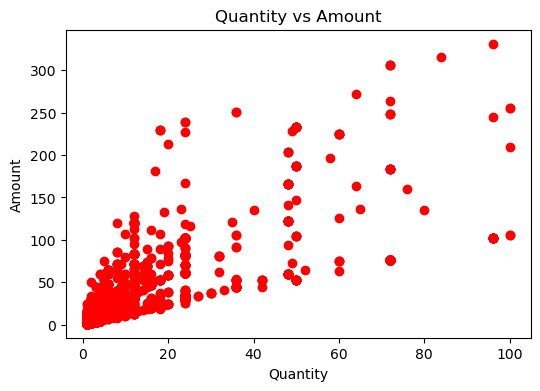

In [48]:
#Melihat Regresi antara quantity dan amount
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_plt.scatter(data_scatter['quantity'], data_scatter['amount'], color = 'red', marker = 'o')
Endy_plt.title('Quantity vs Amount')
Endy_plt.xlabel('Quantity')
Endy_plt.ylabel('Amount')
Endy_plt.show()

### Boxplot

In [49]:
data_boxplot = data_bersih[data_bersih['product_name'].str.contains('coffe')]
data_boxplot

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,date,order_status,amount,price_category
276,493444,21869,potting shed coffee mug,2,2010-01-04 13:47:00,1.25,16792.0,2010-01,2010-01-04,Delivered,2.50,Cheap
617,493667,20748,kensington coffee set,18,2010-01-05 12:13:00,3.95,13253.0,2010-01,2010-01-05,Delivered,71.10,Cheap
702,493671,37370,retro coffee mugs assorted,12,2010-01-05 12:25:00,1.25,13338.0,2010-01,2010-01-05,Delivered,15.00,Cheap
808,493695,21398,red spotty coffee mug,1,2010-01-05 13:23:00,2.10,14606.0,2010-01,2010-01-05,Delivered,2.10,Cheap
851,493696,21216,"set 3 red spot tin tea,coffee,sugar",24,2010-01-05 13:32:00,4.25,16779.0,2010-01,2010-01-05,Delivered,102.00,Cheap
...,...,...,...,...,...,...,...,...,...,...,...,...
283399,539647,37370,retro coffee mugs assorted,6,2010-12-20 16:08:00,1.25,15460.0,2010-12,2010-12-20,Delivered,7.50,Cheap
283421,539647,37370,retro coffee mugs assorted,3,2010-12-20 16:08:00,1.25,15460.0,2010-12,2010-12-20,Delivered,3.75,Cheap
283752,539760,22301,coffee mug cat + bird design,6,2010-12-21 17:16:00,2.55,17400.0,2010-12,2010-12-21,Delivered,15.30,Cheap
283753,539760,22970,london bus coffee mug,6,2010-12-21 17:16:00,2.55,17400.0,2010-12,2010-12-21,Delivered,15.30,Cheap


Text(0.5, 1.0, 'Boxplot Quantity')

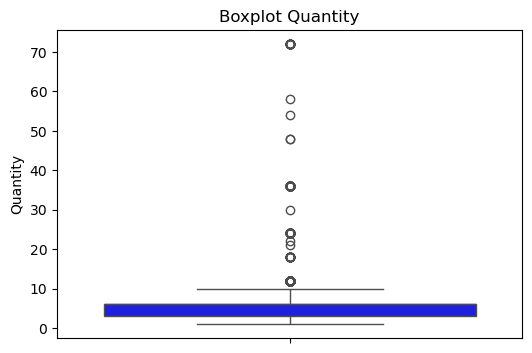

In [50]:
#Boxplot Quantity
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_sea.boxplot(data = data_boxplot, y = 'quantity', color = 'blue')
Endy_plt.ylabel('Quantity')
Endy_plt.title('Boxplot Quantity')

Text(0.5, 1.0, 'Boxplot Amount')

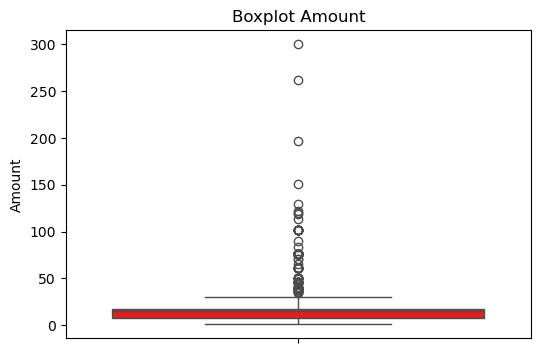

In [51]:
#Boxplot amount
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_sea.boxplot(data = data_boxplot, y = 'amount', color = 'red')
Endy_plt.ylabel('Amount')
Endy_plt.title('Boxplot Amount')

### Heatmap

In [60]:
data_heatmap = data_bersih[['price', 'quantity', 'amount']]
data_heatmap

,price,quantity,amount
0,4.25,1,4.25
1,2.55,36,91.80
2,4.25,12,51.00
3,2.55,2,5.10
4,4.25,2,8.50
...,...,...,...
284128,1.25,1,1.25
284129,1.69,1,1.69
284130,1.69,1,1.69
284131,4.95,2,9.90


In [52]:
data_bersih.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279024 entries, 0 to 284132
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        279024 non-null  object        
 1   product_code    279024 non-null  object        
 2   product_name    279024 non-null  object        
 3   quantity        279024 non-null  int64         
 4   order_date      279024 non-null  datetime64[ns]
 5   price           279024 non-null  float64       
 6   customer_id     279024 non-null  object        
 7   year_month      279024 non-null  period[M]     
 8   date            279024 non-null  object        
 9   order_status    279024 non-null  object        
 10  amount          279024 non-null  float64       
 11  price_category  279024 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(6), period[M](1)
memory usage: 25.8+ MB


Text(0.5, 1.0, 'Heatmap Korelasi')

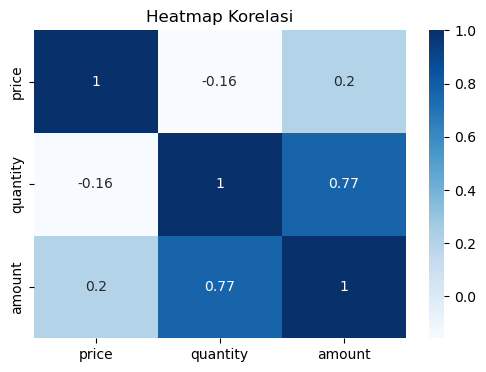

In [66]:
#Haetmap Korelasi 
ukuran = Endy_plt.figure(figsize = (6, 4))
Endy_sea.heatmap(data_heatmap.corr(), cmap = "Blues", annot = True)
Endy_plt.title('Heatmap Korelasi')

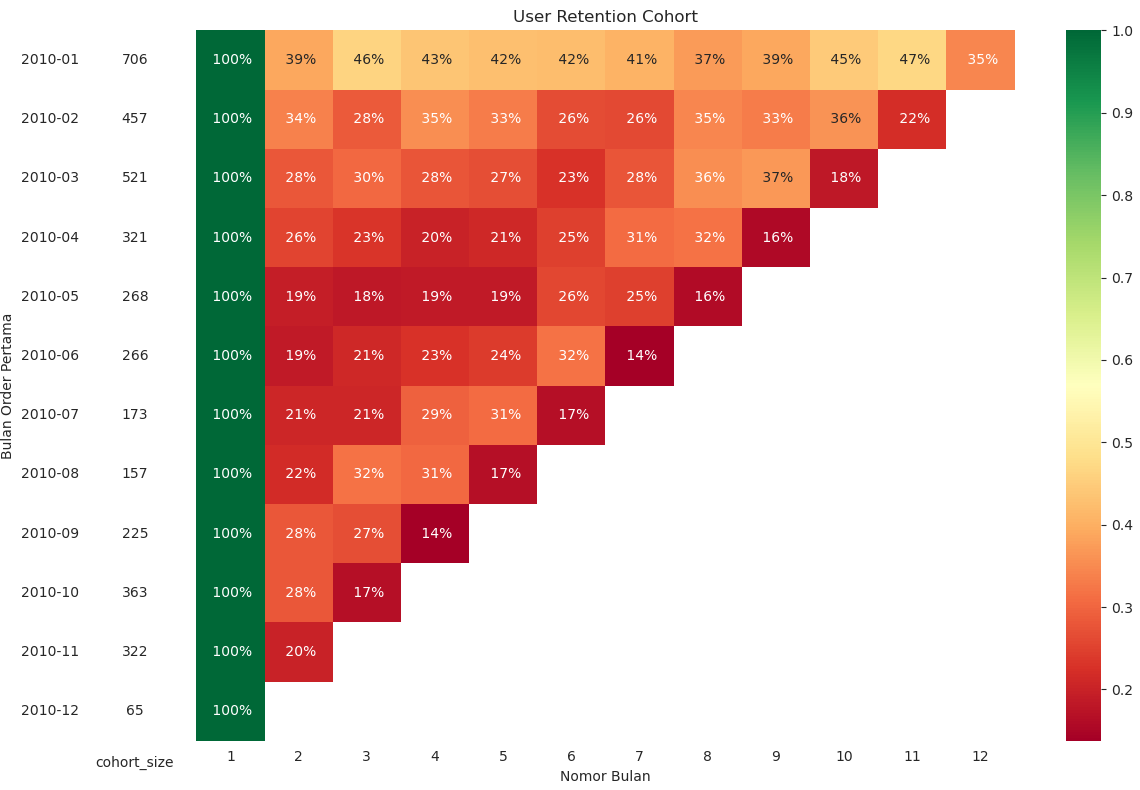

In [107]:
#Heatmap User Retentions Cohort
with Endy_sea.axes_style('white'):
    fig, ax = Endy_plt.subplots(1, 2, figsize = (12, 8), sharey = True, gridspec_kw = {'width_ratios': [1, 11]})

    #User Retention
    Endy_sea.heatmap(data_retention, annot = True, cmap = 'RdYlGn', fmt = ' .0%', ax=ax[1])
    ax[1].set_title('User Retention Cohort')
    ax[1].set(xlabel = 'Nomor Bulan', ylabel = '')

    #Cohort Size
    data_pembagi_cohort = Endy_pd.DataFrame(pembagi_cohort)
    white_cmap = Endy_cl.ListedColormap(['white'])
    Endy_sea.heatmap(data_pembagi_cohort, cbar = False, annot = True, fmt = 'g', cmap = white_cmap, ax=ax[0])
    ax[0].tick_params(bottom = False)
    ax[0].set(ylabel = "Bulan Order Pertama", xlabel = 'cohort_size', xticklabels = [])

    fig.tight_layout()
    Endy_plt.setp(ax[0].get_yticklabels(), rotation=0)

## ExDA

### Pivot Table

In [108]:
#Pivot table user tiap bulan
data_bulanan_customer = data_bersih.groupby(['customer_id', 'year_month'], as_index = False).agg(
    order_count = ('order_id', 'nunique')
)
data_bulanan_customer

,customer_id,year_month,order_count
0,12346.0,2010-01,1
1,12346.0,2010-03,1
2,12346.0,2010-06,2
3,12346.0,2010-10,1
4,12608.0,2010-10,1
...,...,...,...
11888,18286.0,2010-06,1
11889,18286.0,2010-08,1
11890,18287.0,2010-05,1
11891,18287.0,2010-09,2


In [109]:
data_bulanan_customer['cohort'] = data_bulanan_customer.groupby('customer_id')['year_month'].transform('min')
data_bulanan_customer

,customer_id,year_month,order_count,cohort
0,12346.0,2010-01,1,2010-01
1,12346.0,2010-03,1,2010-01
2,12346.0,2010-06,2,2010-01
3,12346.0,2010-10,1,2010-01
4,12608.0,2010-10,1,2010-10
...,...,...,...,...
11888,18286.0,2010-06,1,2010-06
11889,18286.0,2010-08,1,2010-06
11890,18287.0,2010-05,1,2010-05
11891,18287.0,2010-09,2,2010-05


In [111]:
data_bulanan_customer['period_num'] = (data_bulanan_customer['year_month'] - data_bulanan_customer['cohort']).apply(attrgetter('n')) + 1
data_bulanan_customer

,customer_id,year_month,order_count,cohort,period_num
0,12346.0,2010-01,1,2010-01,1
1,12346.0,2010-03,1,2010-01,3
2,12346.0,2010-06,2,2010-01,6
3,12346.0,2010-10,1,2010-01,10
4,12608.0,2010-10,1,2010-10,1
...,...,...,...,...,...
11888,18286.0,2010-06,1,2010-06,1
11889,18286.0,2010-08,1,2010-06,3
11890,18287.0,2010-05,1,2010-05,1
11891,18287.0,2010-09,2,2010-05,5


In [112]:
data_cohort_pivot = Endy_pd.pivot_table(
    data_bulanan_customer, index = 'cohort', columns = 'period_num',
    values = 'customer_id', aggfunc = Endy_pd.Series.nunique
)
data_cohort_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,706.0,274.0,327.0,307.0,300.0,298.0,287.0,263.0,275.0,315.0,332.0,244.0
2010-02,457.0,154.0,130.0,162.0,151.0,120.0,119.0,158.0,152.0,166.0,100.0,NaN
2010-03,521.0,146.0,158.0,144.0,140.0,118.0,144.0,185.0,192.0,95.0,NaN,NaN
2010-04,321.0,82.0,74.0,64.0,68.0,79.0,99.0,102.0,50.0,NaN,NaN,NaN
2010-05,268.0,52.0,49.0,50.0,50.0,69.0,66.0,43.0,NaN,NaN,NaN,NaN
2010-06,266.0,50.0,56.0,60.0,64.0,85.0,37.0,NaN,NaN,NaN,NaN,NaN
2010-07,173.0,36.0,36.0,51.0,53.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,157.0,34.0,50.0,48.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,225.0,63.0,60.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
pembagi_cohort = data_cohort_pivot.iloc[:, 0]
pembagi_cohort

cohort
2010-01    706.0
2010-02    457.0
2010-03    521.0
2010-04    321.0
2010-05    268.0
2010-06    266.0
2010-07    173.0
2010-08    157.0
2010-09    225.0
2010-10    363.0
2010-11    322.0
2010-12     65.0
Freq: M, Name: 1, dtype: float64

In [114]:
data_retention = data_cohort_pivot.divide(pembagi_cohort, axis = 0)
data_retention

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.388102,0.463173,0.434844,0.424929,0.422096,0.406516,0.372521,0.389518,0.446176,0.470255,0.345609
2010-02,1.0,0.336980,0.284464,0.354486,0.330416,0.262582,0.260394,0.345733,0.332604,0.363239,0.218818,NaN
2010-03,1.0,0.280230,0.303263,0.276392,0.268714,0.226488,0.276392,0.355086,0.368522,0.182342,NaN,NaN
2010-04,1.0,0.255452,0.230530,0.199377,0.211838,0.246106,0.308411,0.317757,0.155763,NaN,NaN,NaN
2010-05,1.0,0.194030,0.182836,0.186567,0.186567,0.257463,0.246269,0.160448,NaN,NaN,NaN,NaN
2010-06,1.0,0.187970,0.210526,0.225564,0.240602,0.319549,0.139098,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.208092,0.208092,0.294798,0.306358,0.167630,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.216561,0.318471,0.305732,0.165605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.280000,0.266667,0.137778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualisasi

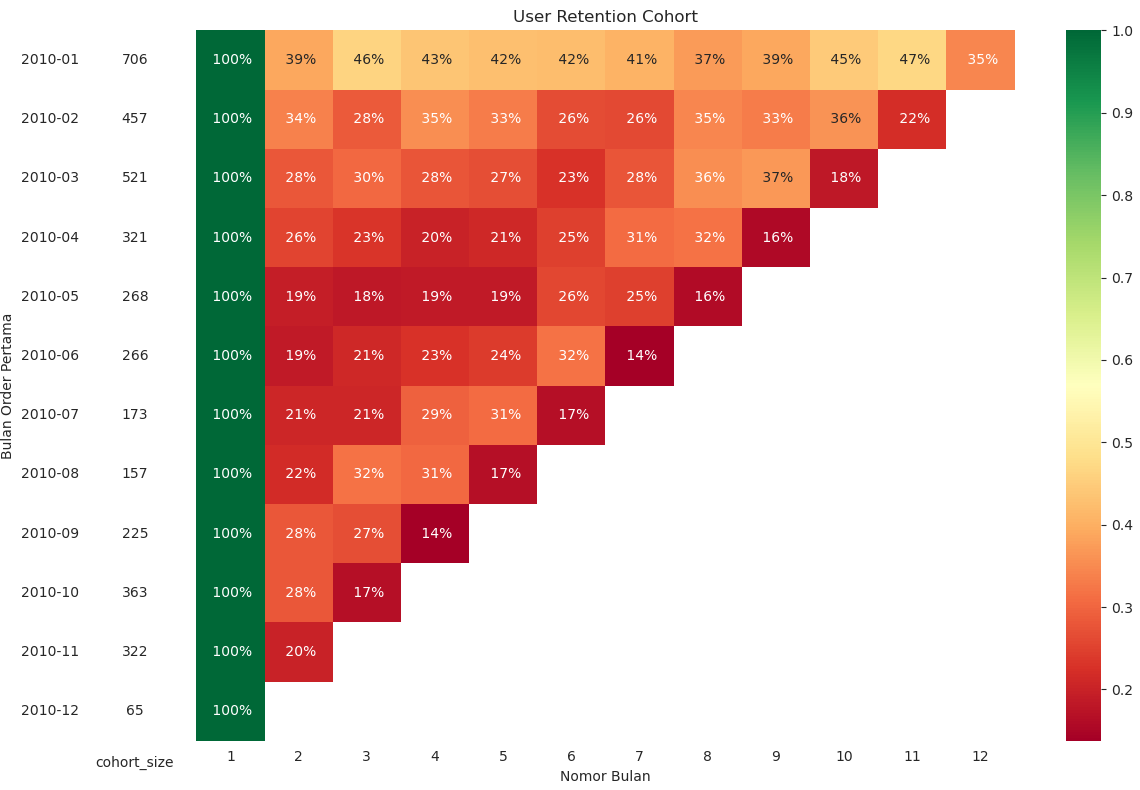

In [115]:
#Heatmap User Retentions Cohort
with Endy_sea.axes_style('white'):
    fig, ax = Endy_plt.subplots(1, 2, figsize = (12, 8), sharey = True, gridspec_kw = {'width_ratios': [1, 11]})

    #User Retention
    Endy_sea.heatmap(data_retention, annot = True, cmap = 'RdYlGn', fmt = ' .0%', ax=ax[1])
    ax[1].set_title('User Retention Cohort')
    ax[1].set(xlabel = 'Nomor Bulan', ylabel = '')

    #Cohort Size
    data_pembagi_cohort = Endy_pd.DataFrame(pembagi_cohort)
    white_cmap = Endy_cl.ListedColormap(['white'])
    Endy_sea.heatmap(data_pembagi_cohort, cbar = False, annot = True, fmt = 'g', cmap = white_cmap, ax=ax[0])
    ax[0].tick_params(bottom = False)
    ax[0].set(ylabel = "Bulan Order Pertama", xlabel = 'cohort_size', xticklabels = [])

    fig.tight_layout()
    Endy_plt.setp(ax[0].get_yticklabels(), rotation=0)